K = 1, Accuracy = 0.717
K = 3, Accuracy = 0.703
K = 5, Accuracy = 0.697
K = 7, Accuracy = 0.711
K = 9, Accuracy = 0.700
K = 11, Accuracy = 0.717
K = 13, Accuracy = 0.717
K = 15, Accuracy = 0.735
K = 17, Accuracy = 0.706
K = 19, Accuracy = 0.714


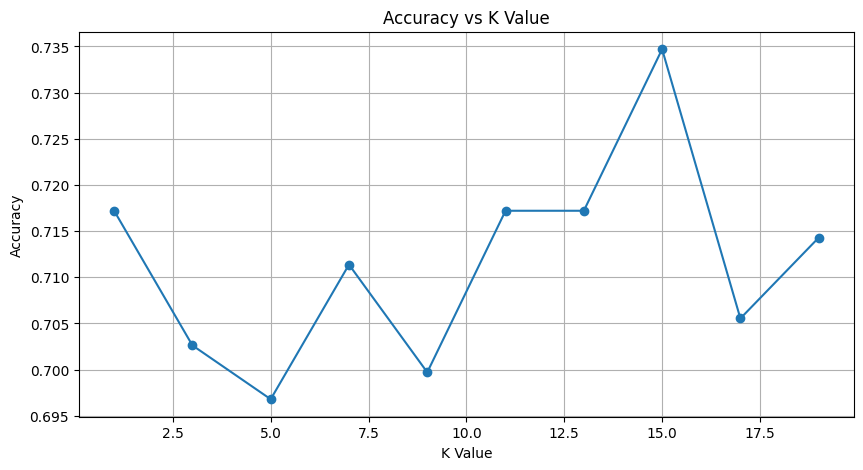


Best K value: 15


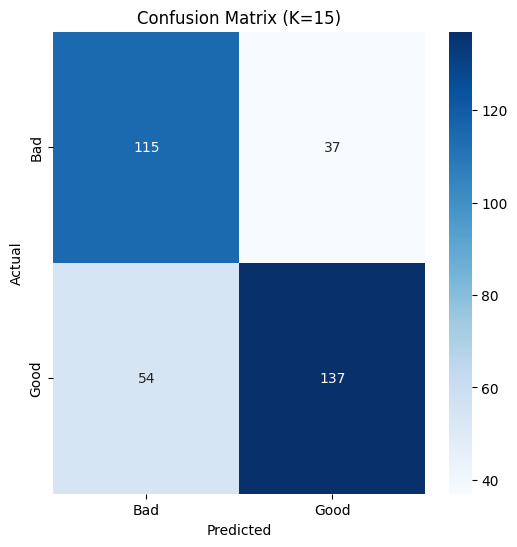

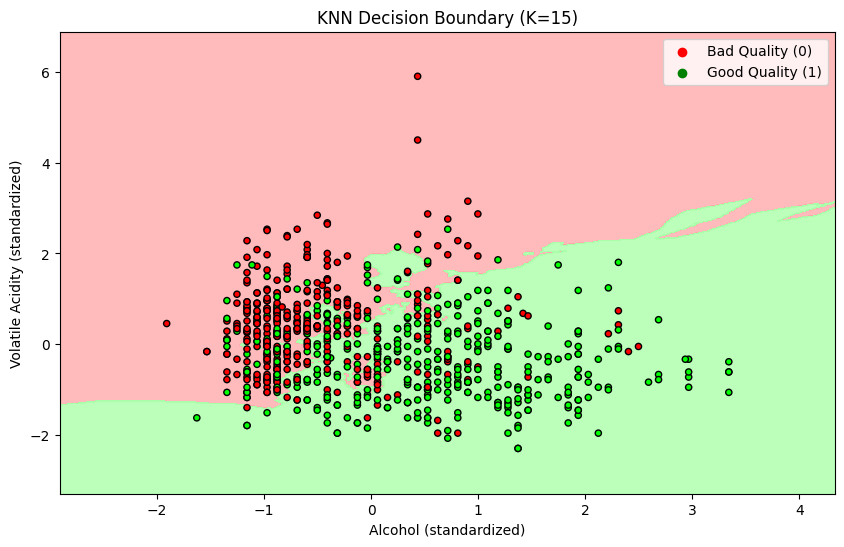

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.colors import ListedColormap
import seaborn as sns

# 1. Load and prepare the data
df = pd.read_csv('WineQT.csv')

# Select features and target
X = df[['alcohol', 'volatile acidity']]  # Using two features for visualization
y = df['quality']

# Convert to binary classification (quality >= 6 is good)
y = (y >= 6).astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Experiment with different K values
k_values =list(range(1, 20, 2))
results = []

for k in k_values:
    # Create and train KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = knn.predict(X_test_scaled)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results.append(acc)
    
    print(f"K = {k}, Accuracy = {acc:.3f}")

# Plot accuracy vs K values
plt.figure(figsize=(10, 5))
plt.plot(k_values, results, marker='o')
plt.title('Accuracy vs K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# 3. Evaluate with confusion matrix for best K
best_k = k_values[np.argmax(results)]
print(f"\nBest K value: {best_k}")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bad', 'Good'], 
            yticklabels=['Bad', 'Good'])
plt.title('Confusion Matrix (K={})'.format(best_k))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. Visualize decision boundaries
def plot_decision_boundary(X, y, classifier, title):
    h = 0.02  # step size in the mesh
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict for each point in mesh
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA']), alpha=0.8)
    
    # Plot training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF0000', '#00FF00']),
                edgecolor='k', s=20)
    plt.xlabel('Alcohol (standardized)')
    plt.ylabel('Volatile Acidity (standardized)')
    plt.title(title)
    
    # Legend
    plt.scatter([], [], c='red', label='Bad Quality (0)')
    plt.scatter([], [], c='green', label='Good Quality (1)')
    plt.legend()
    plt.show()

# Plot for best K
plot_decision_boundary(X_train_scaled, y_train, knn_best, 
                      f'KNN Decision Boundary (K={best_k})')